# L1 route (e) — the flare visual pass

This notebook does one thing: **draw flare-positive and flare-negative light curves so a human can look at them.**

It is a gate, not a report. Under decision D21 plus the user's 2026-08-26 reporting rule (B), `flare` is
printable in the ML4PS paper **only** with two defenses: the negative-set audit (done,
`experiments/l1_flare_negatives_README.md`) **and** this manual pass. No number here decides anything.

## The five populations, and what each one asks

`flare_ever` conflates two label defects that run in opposite directions, so "positive" and "negative"
each split. Every panel is drawn independently and answers its own question.

| row | population | what your eye is checking |
|---|---|---|
| 1 | positive, flare on screen | does a catalogued flare actually look like a flare in our packed data? **calibrates the eye** |
| 2 | positive, no flare on screen | 81% of the positive class. these are what the probe is asked to detect |
| 3 | **negative, searched-and-clean** | **the D21(e) gate: do these show flares the catalog missed?** |
| 4 | negative, never-searched | what the old negative class was silently mixing in |
| 5 | **model-positive / label-negative** | **the sharp test: the model's top-ranked negatives, each one demonstrably searched and cleared** |

## Vocabulary

```
event coverage   does a catalogued flare peak land on a cadence we actually packed?
                 measured 19.4% at the segment the eval encodes -> rows 1 vs 2

sigma_ratio      STD(31-point running median of flux) / STD(flux)      [Seli+2025 Eq. 1]
                 flatwrm2 searched a light curve only if sigma_ratio > 0.4
                 > 0.4  -> searched-and-clean, a real negative      -> row 3
                 <= 0.4 -> never searched, carries no information   -> row 4
```

## Decision rule, fixed before looking

```
rows 3 and 5 show no flare-like spikes  ->  the negatives are real; the null is confirmed visually
                                            and flare may be printed as a caveated null

rows 3 or 5 show obvious flares         ->  label artifact: the catalogs miss real flares.
                                            that is the W7-adjacent finding, worth a sentence in the
                                            paper, and it is v2 material -- NEVER printed as a detection
```

**What this pass does not say.** Row 1 looking convincing does not validate the probe; row 2 looking
flat is expected and is not evidence the label is wrong at star level, because flare *propensity* is a
real stellar property that survives a quiet sector.

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
while not (repo_root / "CLAUDE.md").exists():
    repo_root = repo_root.parent

sigma_ratio_threshold = 0.4 # Seli+2025 Eq. (1)

catalog = pd.read_csv(repo_root / "data" / "Table3_flare_catalog.csv")
universe = pd.read_parquet(repo_root / "labels" / "qc" / "flare_search_universe.parquet")
window_labels = pd.read_parquet(repo_root / "labels" / "qc" / "flare_window_labels_pool.parquet")
star_scores = pd.read_parquet(repo_root / "experiments" / "l1_flare_negatives" / "l1_star_scores.parquet")
pool = pd.read_parquet(repo_root / "processed" / "subset" / "new_task_pool.parquet")
canon = pd.read_csv(repo_root / "labels" / "variability_labels_star.csv")
canon["tic_id"] = canon["tic_id"].astype(int)
canon["flare"] = pd.to_numeric(canon["flare_ever"], errors="coerce").fillna(0).astype(int)

print("loaded from", repo_root)

loaded from c:\git_repo\Stellar-World-Model


## Build the five populations

```
positive        flare_ever = 1
  covered         >= 1 catalogued peak inside a window the eval encodes
  not covered     otherwise

negative        flare_ever = 0
  searched        sigma_ratio > 0.4 in some sector <= 69 that we hold
  never searched  we hold S<=69 data and it never clears 0.4
  (a star with no S<=69 data at all is `unknown` and is excluded from both)

model_positive  searched-and-clean negatives, ranked by the held-out fusion score,
                seed-averaged over the 6 hann0p3_fbwd seeds of the `neg_searched` cell
```

In [2]:
covered = set(window_labels.groupby("tic_id")["label"].max().loc[lambda s: s > 0].index.astype(int))
searched = set(universe.loc[universe["sigma_ratio_sector"] > sigma_ratio_threshold, "tic_id"].astype(int))
has_flatwrm2_data = set(universe["tic_id"].astype(int))

pool_tics = set(pool["tic_id"].astype(int))
positive = set(canon.loc[canon["flare"] == 1, "tic_id"]) & pool_tics
negative = (pool_tics - positive) & has_flatwrm2_data

ranked = star_scores[(star_scores["cell"] == "neg_searched")
                     & (star_scores["arm_set"] == "features_plus_mu")
                     & (star_scores["family"] == "hann0p3_fbwd")
                     & (star_scores["y"] == 0)]
ranked = ranked.groupby("tic_id")["score"].mean().sort_values(ascending=False)

populations = {
    "positive, flare on screen": sorted(positive & covered),
    "positive, no flare on screen": sorted(positive - covered),
    "negative, searched-and-clean": sorted(negative & searched),
    "negative, never-searched": sorted(negative - searched),
    "model-positive / label-negative": list(ranked.head(40).index.astype(int)),
}

rows = []
for name, members in populations.items():
    rows.append({"population": name, "n_stars": len(members)})
pd.DataFrame(rows)

,population,n_stars
0,"positive, flare on screen",392
1,"positive, no flare on screen",1630
2,"negative, searched-and-clean",11535
3,"negative, never-searched",4706
4,model-positive / label-negative,40


## Plotting recipe

The curve drawn is the one the model was actually shown: the star's **first segment**, defined as
`min(sector, seg_idx)`, which is how `swm.eval.new_task_extract` picks it. Flux is MAD-normalized per
segment at pack time, so the y-axis is in MAD units and is not comparable between stars.

```
npz -> windows (n_win, 1024, 1) + times (n_win, 1024) -> flatten, sort by time -> plot
red vertical lines = catalogued flare peaks from Seli Table 3 falling inside the plotted span
```

A red line with no spike under it means the catalogued flare is not in these cadences. A spike with no
red line on rows 3 to 5 is the thing this whole pass exists to look for.

In [3]:
npz_re = re.compile(r"^TIC(\d+)_s(\d+)_seg(\d+)_run\d+\.npz$")
wanted = set()
for members in populations.values():
    wanted.update(members)

first_segment = {}
with os.scandir(repo_root / "processed" / "sequences") as entries:
    for entry in entries:
        match = npz_re.match(entry.name)
        if match is None:
            continue
        tic = int(match.group(1))
        if tic not in wanted:
            continue
        key = (int(match.group(2)), int(match.group(3)))
        if tic not in first_segment or key < first_segment[tic][0]:
            first_segment[tic] = (key, Path(entry.path))

peaks_by_tic = catalog.groupby("TIC")["peak_time"].apply(list)


def curve(tic):
    """
    The first-segment light curve the eval encodes for one star, as (times, flux) in time order.
    Windows discarded at pack time leave real gaps, so the series is plotted against its times rather
    than against a cadence index.
    """
    payload = np.load(first_segment[tic][1])
    times = payload["times"].reshape(-1)
    flux = payload["windows"].reshape(-1)
    order = np.argsort(times)
    return times[order], flux[order]


print("indexed first segment for", len(first_segment), "stars")

indexed first segment for 18263 stars


## The figure

One row per population, three stars per row, **a fresh random draw on every re-run**. Re-run it several
times before recording a verdict: a single draw of three is not a survey.

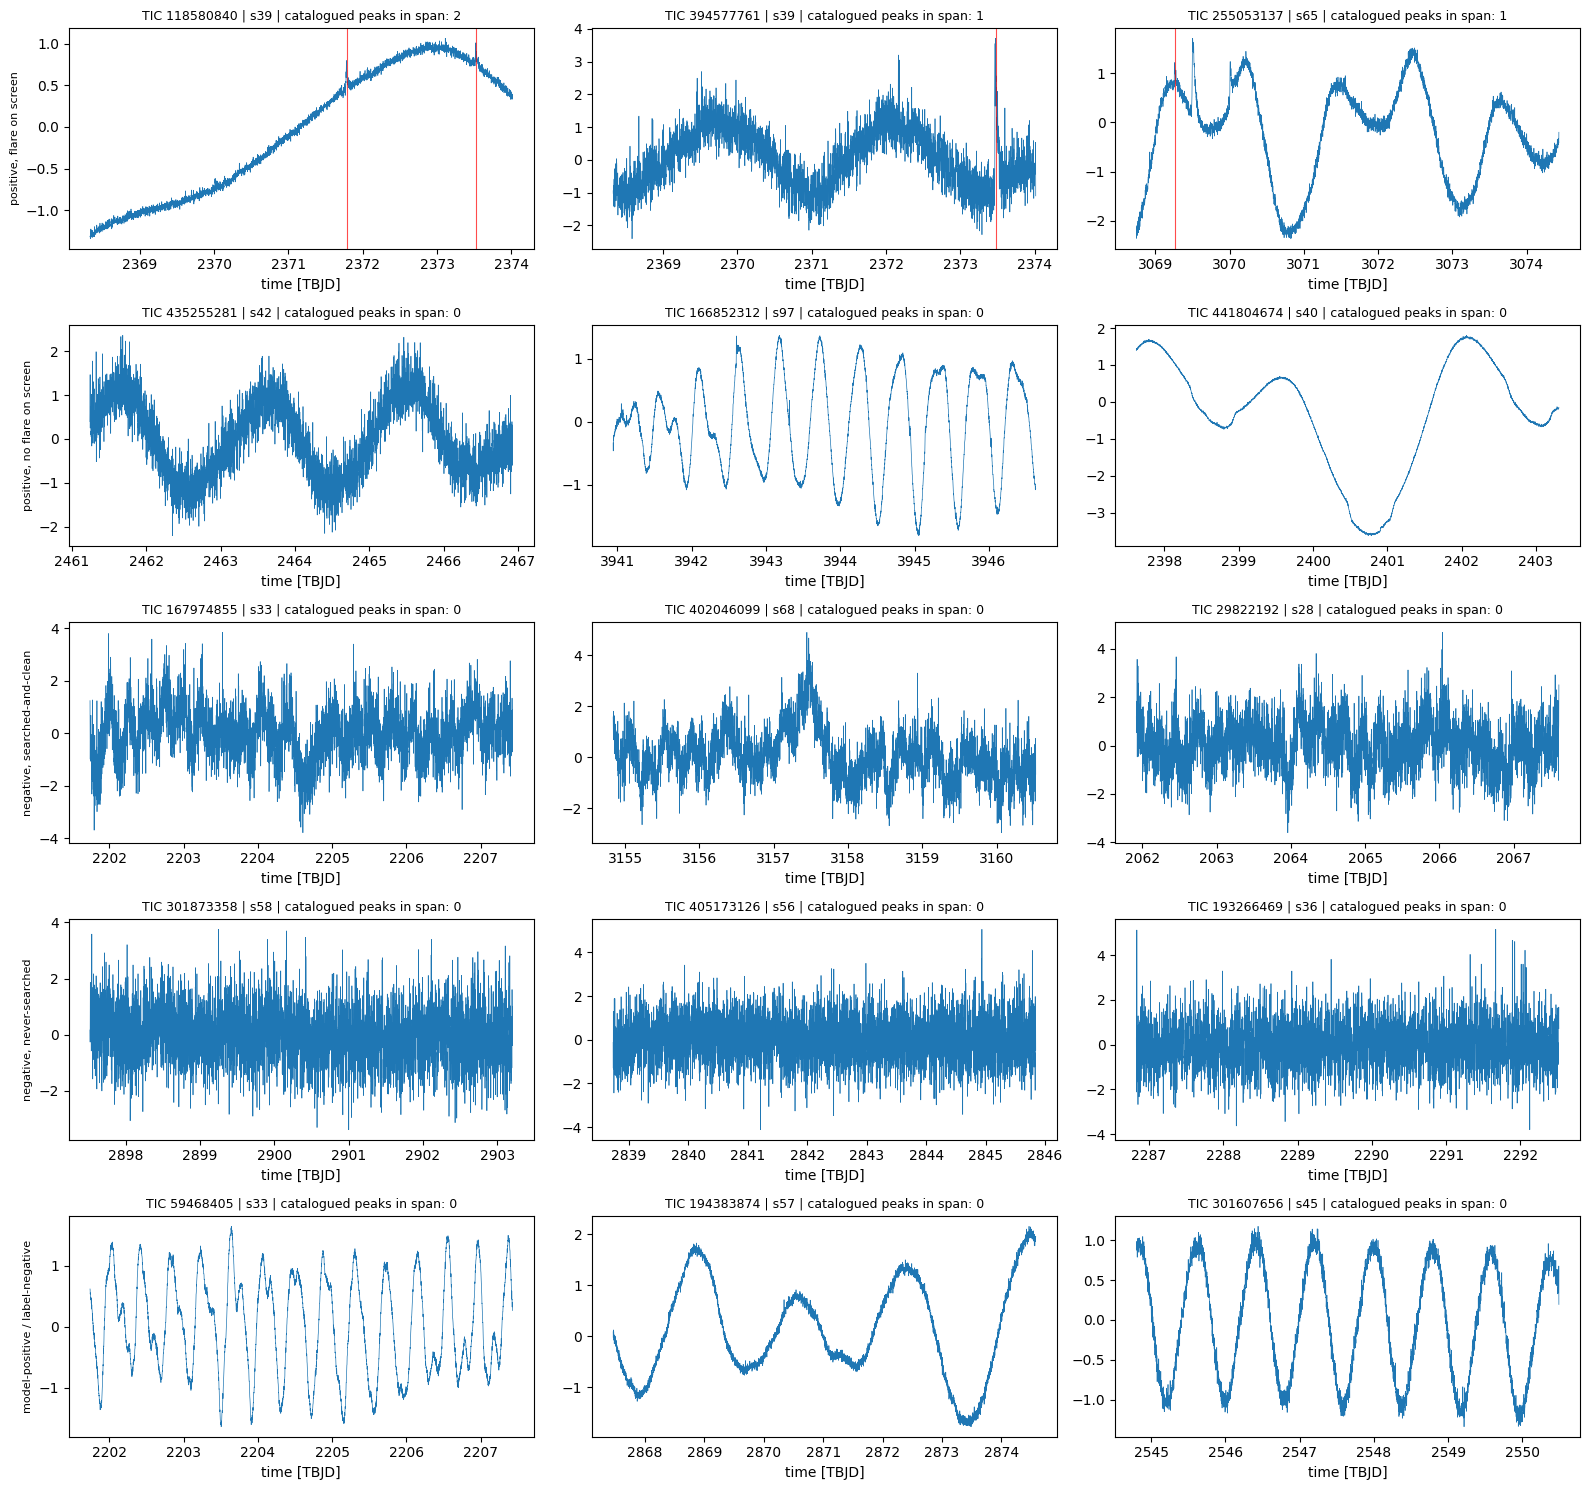

In [6]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0) # uncomment for a reproducible sample

n_per_row = 3
plt.figure(figsize=(16, 3.0 * len(populations)))
panel = 1
for name, members in populations.items():
    drawable = []
    for tic in members:
        if tic in first_segment:
            drawable.append(tic)
    picks = rng.choice(drawable, size=min(n_per_row, len(drawable)), replace=False)
    for tic in picks:
        tic = int(tic)
        times, flux = curve(tic)
        plt.subplot(len(populations), n_per_row, panel)
        plt.plot(times, flux, lw=0.5)
        n_marked = 0
        for peak in peaks_by_tic.get(tic, []):
            if times.min() <= peak <= times.max():
                plt.axvline(peak, color="red", lw=0.8, alpha=0.7)
                n_marked += 1
        plt.title(f"TIC {tic} | s{first_segment[tic][0][0]} | catalogued peaks in span: {n_marked}",
                  fontsize=9)
        plt.xlabel("time [TBJD]")
        if panel % n_per_row == 1:
            plt.ylabel(name, fontsize=8)
        panel += 1
plt.tight_layout()
plt.show()

## Record the verdict here

After re-running the figure several times, write one of the two pre-registered outcomes into
`experiments/l1_flare_negatives_README.md` and the ADR-0001 addendum:

- **null confirmed visually** — rows 3 and 5 show no flare-like spikes; `flare` may be printed as a
  caveated null with both defenses.
- **label artifact** — rows 3 or 5 show obvious flares the catalogs missed; record as the W7-adjacent
  finding and v2 material, never as a detection.

The verdict is the user's to give. This notebook does not compute it.